In [1]:
import pandas as pd

In [3]:
tabela_usinas = pd.read_parquet("tabela_usinas.parquet")

### Calcula índices de flexibilidade para cada subsistema
- O cálculo é feito para cada subsistema do SIN, considerando 1, 2, 4 e 6 horas de rampa.
- O cálculo considera as fontes solar e eólica de forma negativa (demanda de flexibilidade)
- Enquanto considera outras fontes são consideradas de forma positiva (oferta de flexibilidade).

In [ ]:
filtro_sistema = tabela_usinas['id_subsistema'] == 'S'
filtro_REN = tabela_usinas['nom_tipousina'].isin(['EOLIELÉTRICA', 'FOTOVOLTAICA'])
filtro_oferta = filtro_sistema & ~filtro_REN
filtro_demanda = filtro_sistema & filtro_REN
for horas in [1, 2, 4, 6]:
    cap_instalada = tabela_usinas.loc[filtro_sistema, 'P max'].sum()
    flex_oferta = (tabela_usinas.loc[filtro_oferta, "Ind Flex Up P" + str(horas)] * tabela_usinas.loc[filtro_oferta, 'P max']).sum()
    flex_demanda = (-1*tabela_usinas.loc[filtro_demanda, "Ind Flex Down P" + str(horas)] * tabela_usinas.loc[filtro_demanda, 'P max']).sum()
    flex_NE = (flex_oferta + flex_demanda)/cap_instalada
    print(f"NFI do Nordeste é de: {flex_NE:.2f} ")

NFI do Nordeste é de: 0.37 
NFI do Nordeste é de: 0.41 
NFI do Nordeste é de: 0.40 
NFI do Nordeste é de: 0.39 


### Análise com anos de entrada das usinas

In [2]:
capacidade = pd.read_parquet("capacidade_geracao.parquet")

In [9]:
for usina in tabela_usinas["nom_usina"]:
    mask_capacidade = capacidade["nom_usina"].str.upper() == usina.upper()
    if mask_capacidade.any():
        data_entrada = capacidade.loc[mask_capacidade, "dat_entradaoperacao"].values[0]
        tabela_usinas.loc[tabela_usinas["nom_usina"] == usina, "dat_entradaoperacao"] = data_entrada

In [ ]:
cols = list(tabela_usinas.columns)
cols.remove('dat_entradaoperacao')
idx = cols.index('P max')
cols = cols[:idx] + ['dat_entradaoperacao'] + cols[idx:]
tabela_usinas = tabela_usinas[cols]

In [18]:
usinas_datas = {
    "BBF Baliza": "2024-04-11",
    "Alto Jatapu": "1994-01-01",
    "Conj. Paulino Neves": "2017-11-07",
    "Cristiano Rocha": "2007-12-18",
    "Distrito": "1990-12-31"
    # "MC2 Nova Venécia 2":
    # "Manauara"
    # "PQU ACRAC FOTOV MMGD"
    # "PQU MAMA FOTOV MMGD"
    # "PQU MAMA TERM - CARGA GLOBAL"
    # "PQU MATO FOTOV MMGD"
    # "PQU MMAM FOTOV MMGD"
    # "PQU MMAP FOTOV MMGD"
    # "PQU MMPA FOTOV MMGD"
    # "PQU PA TERM - CARGA GLOBAL"
    # "PQU PAPA FOTOV MMGD"
    # "PQU PATR FOTOV MMGD"
    # "PQU RRRR FOTOV MMGD"
    # "PQU TO NORTE FOTOV - CARGA GLOBAL"
    # "PQU TO NORTE HIDRA - CARGA GLOBAL"
    # "PQU TO NORTE TER - CARGA GLOBAL"
    # "Ponta Negra"
    # "Cataventos Acaraú I"
    # "Conj. Abaiara 230 kV"
    # "Conj. Abil I"
    # "Conj. Abil II"
    # "Conj. Acaraú II"
    # "Conj. Acauã"
    # "Conj. Afonso Bezerra"
    # "Conj. Alex"
    # "Conj. Amazonas"
    # "Conj. Anemus"
    # "Conj. Aracati II"
    # "Conj. Araripe III"
    # "Conj. Araçás"
    # "Conj. Areia Branca"
    # "Conj. Arizona"
    # "Conj. Asa Branca"
    # "Conj. Assu Sol"
    # "Conj. Aventura"
    # "Conj. Açú III 230 kV"
    # "Conj. BJL"
    # "Conj. BW Guirapá I"
    # "Conj. BW Guirapá II"
    # "Conj. Babilônia"
    # "Conj. Babilônia Centro"
    # "Conj. Babilônia Sul"
    # "Conj. Baixa do Feijão"
    # "Conj. Banabuiu"
    # "Conj. Banabuiú"
    # "Conj. Barreiras"
    # "Conj. Barreiras II 500 kV"
    # "Conj. Belmonte"
    # "Conj. Bloco Sul"
    # "Conj. Bom Jesus"
    # "Conj. Bom Nome"
    # "Conj. Brisa Potiguar I"
    # "Conj. Brotas de Macaúbas"
    # "Conj. Brígida"
    # "Conj. Cabeço Preto II"
    # "Conj. Cacimbas"
    # "Conj. Caetité"
    # "Conj. Caetité 123"
    # "Conj. Caetité A"
    # "Conj. Caetité Norte"
    # "Conj. Caetés II"
    # "Conj. Caju"
    # "Conj. Calango 1"
    # "Conj. Calango 2"
    # "Conj. Calango 3"
    # "Conj. Calcário"
    # "Conj. Campo Formoso"
    # "Conj. Campo Largo"
    # "Conj. Campo Largo 2"
    # "Conj. Campo dos Ventos"
    # "Conj. Canudos I"
    # "Conj. Carcará II"
    # "Conj. Carnaúbas"
    # "Conj. Casa Nova"
    # "Conj. Chafariz Norte"
    # "Conj. Chafariz Sul I"
    # "Conj. Chafariz Sul II"
    # "Conj. Chapada I"
    # "Conj. Chapada II"
    # "Conj. Chapada III"
    # "Conj. Chapadinha"
    # "Conj. Ciranda"
    # "Conj. Cristal"
    # "Conj. Cristalândia"
    # "Conj. Cumaru"
    # "Conj. Curral Novo do Piaui II 500 kV"
    # "Conj. Curva dos Ventos"
    # "Conj. Cutia"
    # "Conj. Delfina"
    # "Conj. Eolico Serra do Assurua"
    # "Conj. Eólico Campo Largo"
    # "Conj. Eólico Igaporã III 500kV"
    # "Conj. Eólico Mossoró II 230kV"
    # "Conj. Eólico Pindaí II 230kV"
    # "Conj. Eólico Umari"
    # "Conj. FV SJP"
    # "Conj. Faísa"
    # "Conj. Filgueira"
    # "Conj. Floresta"
    # "Conj. Folha Larga"
    # "Conj. Folha Larga Sul"
    # "Conj. Folha de Serra"
    # "Conj. Fotov. Acu III 230KV"
    # "Conj. Fotov. Assu Sol 500KV"
    # "Conj. Fotov. Simplice"
    # "Conj. Fotovoltaico Abaiara 230 kV"
    # "Conj. Fotovoltaico Barreiras II 500 kV"
    # "Conj. Fotovoltaico Gilbués II 500 kV"
    # "Conj. Futura"
    # "Conj. GPEXPAN"
    # "Conj. Gameleira"
    # "Conj. Gentio do Ouro I"
    # "Conj. Gilbués II 500 kV"
    # "Conj. Guirapá"
    # "Conj. Horizonte"
    # "Conj. Icaraí"
    # "Conj. Igaporã II"
    # "Conj. Igaporã III 500 kV"
    # "Conj. Itarema V"
    # "Conj. Ituverava"
    # "Conj. Jandaia"
    # "Conj. Jandaíra I"
    # "Conj. Jandaíra III"
    # "Conj. Jerusalém"
    # "Conj. Juazeiro Solar"
    # "Conj. Juazeiro Solar 2"
    # "Conj. Kairos"
    # "Conj. Lagoa do Barro I"
    # "Conj. Lagoa dos Ventos"
    # "Conj. Lagoa dos Ventos 1"
    # "Conj. Lagoa dos Ventos 2"
    # "Conj. Lapa"
    # "Conj. Laranjeiras"
    # "Conj. Lavras"
    # "Conj. Licínio de Almeida"
    # "Conj. Lins"
    # "Conj. Luzia"
    # "Conj. Macacos"
    # "Conj. Mangue Seco"
    # "Conj. Marangatu"
    # "Conj. Mauriti"
    # "Conj. Modelo"
    # "Conj. Monte Verde"
    # "Conj. Monte Verde Solar"
    # "Conj. Monte do Ronca"
    # "Conj. Morro do Chapéu Sul"
    # "Conj. Morro do Chapéu Sul II"
    # "Conj. Morro dos Ventos"
    # "Conj. Morro dos Ventos II"
    # "Conj. Morrão"
    # "Conj. Mossoró II"
    # "Conj. Mundo Novo"
    # "Conj. N. S. da Conceição"
    # "Conj. Nova Olinda"
    # "Conj. Novo Horizonte"
    # "Conj. Oeste Serido"
    # "Conj. Oeste Seridó"
    # "Conj. Oitis"
    # "Conj. Olho d'Água"
    # "Conj. Ourolândia II"
    # "Conj. Papagaios"
    # "Conj. Paranatama"
    # "Conj. Pedra Branca"
    # "Conj. Pedra Cheirosa"
    # "Conj. Pelourinho"
    # "Conj. Pindai"
    # "Conj. Pindaí II 230 kV"
    # "Conj. Pitombeira"
    # "Conj. Planaltina"
    # "Conj. Quina"
    # "Conj. Renascença"
    # "Conj. Renascença V"
    # "Conj. Riachão"
    # "Conj. Ribeiro Gonçalves"
    # "Conj. Rio Alto"
    # "Conj. Rio do Vento"
    # "Conj. Rio do Vento Expansão"
    # "Conj. Santa Clara"
    # "Conj. Santa Eugênia"
    # "Conj. Santa Luzia II 500 kV"
    # "Conj. Santa Rosa Mundo Novo"
    # "Conj. Santa Rosália"
    # "Conj. Santo Agostinho"
    # "Conj. Santo Inácio"
    # "Conj. Serra Azul"
    # "Conj. Serra da Babilônia"
    # "Conj. Serra de Santana 1 e 2"
    # "Conj. Serra de Santana 3"
    # "Conj. Serra do Assuruá"
    # "Conj. Serra do Mato"
    # "Conj. Serra do Mel A"
    # "Conj. Serra do Mel B"
    # "Conj. Serra do Mel C"
    # "Conj. Serra do Mel II A"
    # "Conj. Serra do Mel II B"
    # "Conj. Serra do Seridó"
    # "Conj. Serrote"
    # "Conj. Serrote A"
    # "Conj. Sertão Solar Barreiras"
    # "Conj. Simplice"
    # "Conj. Sol do Futuro"
    # "Conj. Sol do Sertão"
    # "Conj. São Basílio (Eólico)"
    # "Conj. São Basílio (Solar)"
    # "Conj. São Clemente"
    # "Conj. São Gonçalo"
    # "Conj. São Gonçalo A"
    # "Conj. São Miguel"
    # "Conj. São Pedro"
    # "Conj. São Roque"
    # "Conj. Tacaratu"
    # "Conj. Tacaratu (Eólico)"
    # "Conj. Tacaratu (Solar)"
    # "Conj. Tacaratu II"
    # "Conj. Tamboril I"
    # "Conj. Tamboril II"
    # "Conj. Tanque Novo"
    # "Conj. Taíba"
    # "Conj. Terra Santa"
    # "Conj. Trairí"
    # "Conj. Tucano"
    # "Conj. Umari"
    # "Conj. Umburanas"
    # "Conj. União dos Ventos"
    # "Conj. Ventos da Bahia"
    # "Conj. Ventos da Bahia 2"
    # "Conj. Ventos da Bahia III"
    # "Conj. Ventos de São Vitor"
    # "Conj. Ventos do Piauí II"
    # "Conj. Ventos do Piauí III"
    # "Conjunto Eólico Babilonia Centro"
    # "Conjunto Eólico Curral Novo do Piaui II 230kV"
    # "Conjunto Eólico Curral Novo do Piaui II 500kV"
    # "Conjunto Eólico Kairos"
    # "Conjunto Eólico Ourolândia II"
    # "Conjunto fotovoltaico Santa Luzia II 500kV"
    # "PQU ALPAL FOTOV MMGD"
    # "PQU ALPEAL HID - CARGA GLOBAL"
    # "PQU ALPEAL TERM - CARGA GLOBAL"
    # "PQU ALPEPB TERM - CARGA GLOBAL"
    # "PQU ALPEPE EOL - CARGA GLOBAL"
    # "PQU ALPEPE FOTOV - CARGA GLOBAL"
    # "PQU ALPEPE HID - CARGA GLOBAL"
    # "PQU ALPEPE TERM - CARGA GLOBAL"
    # "PQU ALPPE FOTOV MMGD"
    # "PQU BAOEBA EOL - CARGA GLOBAL"
    # "PQU BAOEBA FOTOV - CARGA GLOBAL"
    # "PQU BAOEBA HID - CARGA GLOBAL"
    # "PQU BAOEBA TERM - CARGA GLOBAL"
    # "PQU BAOETO HID - CARGA GLOBAL"
    # "PQU BASEBA HID - CARGA GLOBAL"
    # "PQU BASEBA TERM - CARGA GLOBAL"
    # "PQU BASESE EOL - CARGA GLOBAL"
    # "PQU BASESE TERM - CARGA GLOBAL"
    # "PQU BOEBA FOTOV MMGD"
    # "PQU BSCAL FOTOV MMGD"
    # "PQU BSSBA FOTOV MMGD"
    # "PQU BSSES FOTOV MMGD"
    # "PQU CECE EOL - CARGA GLOBAL"
    # "PQU CECE FOTOV - CARGA GLOBAL"
    # "PQU CECE FOTOV MMGD"
    # "PQU CEPB EOL - CARGA GLOBAL"
    # "PQU CEPB FOTOV - CARGA GLOBAL"
    # "PQU CEPB FOTOV MMGD"
    # "PQU CEPB HID - CARGA GLOBAL"
    # "PQU CEPE FOTOV MMGD"
    # "PQU CERN EOL - CARGA GLOBAL"
    # "PQU CERN FOTOV MMGD"
    # "PQU PBRNPB EOL - CARGA GLOBAL"
    # "PQU PBRNRN EOL - CARGA GLOBAL"
    # "PQU PBRNRN FOTOV - CARGA GLOBAL"
    # "PQU PBRNRN TERM - CARGA GLOBAL"
    # "PQU PBRPB FOTOV MMGD"
    # "PQU PBRRN FOTOV MMGD"
    # "PQU PIPI EOL - CARGA GLOBAL"
    # "PQU PIPI FOTOV - CARGA GLOBAL"
    # "PQU PIPI FOTOV MMGD"
    # "PQU PIPI TERM - CARGA GLOBAL"
    # "Arturo Andreoli"
    # "Conj. Atlântica"
    # "Conj. Boca do Monte"
    # "Conj. Bom Jardim"
    # "Conj. Cerro Chato"
    # "Conj. Eólico Livramento 3"
    # "Conj. Klabin Celulose"
    # "Conj. Lagoa dos Barros"
    # "Conj. Lajeado Grande"
    # "Conj. Livramento 3"
    # "Conj. Marmeleiro 2"
    # "Conj. Quinta 138 kV"
    # "Conj. Quinta 69 kV"
    # "Conj. Santa Vitória do Palmar"
    # "Conj. Viamão 3"
    # "Conj. Água Doce"
    # "Energia Madeiras"
    # "Jorge Lacerda I e II"
    # "Jorge Lacerda III"
    # "Jorge Lacerda IV"
    # "PQU PRPR EOL - CARGA GLOBAL"
    # "PQU PRPR FOTOV MMGD"
    # "PQU PRPR HID - CARGA GLOBAL"
    # "PQU PRPR TERM - CARGA GLOBAL"
    # "PQU PRSC EOL - CARGA GLOBAL"
    # "PQU PRSC HID - CARGA GLOBAL"
    # "PQU RSRS EOL - CARGA GLOBAL"
    # "PQU RSRS FOTOV MMGD"
    # "PQU RSRS HID - CARGA GLOBAL"
    # "PQU RSRS TERM - CARGA GLOBAL"
    # "PQU SCRS HID - CARGA GLOBAL"
    # "PQU SCSC EOL - CARGA GLOBAL"
    # "PQU SCSC FOTOV - CARGA GLOBAL"
    # "PQU SCSC FOTOV MMGD"
    # "PQU SCSC HID - CARGA GLOBAL"
    # "PQU SCSC TERM - CARGA GLOBAL"
    # "Pequenas Centrais Hidroelétricas da Ceee"
    # "Alcon"
    # "Angélica"
    # "Bocaiúva"
    # "Caarapó"
    # "Cocal II"
    # "Conj. Alta Mogiana"
    # "Conj. Araxá"
    # "Conj. Arinos 2 500 kV"
    # "Conj. Bio Ipê"
    # "Conj. Biopav"
    # "Conj. Boa Hora"
    # "Conj. Boa Sorte"
    # "Conj. Bracell"
    # "Conj. Cachoeira Dourada"
    # "Conj. Castilho"
    # "Conj. Chapadão"
    # "Conj. Complexo do Prata"
    # "Conj. Da Mata"
    # "Conj. Dourados"
    # "Conj. Dracena"
    # "Conj. Edéia"
    # "Conj. Fazenda"
    # "Conj. Francisco Sá"
    # "Conj. Fíbria"
    # "Conj. Guaimbê"
    # "Conj. Guarani Tanabi"
    # "Conj. Helio Valgas"
    # "Conj. Interlagos"
    # "Conj. Ivinhema 2"
    # "Conj. Jaiba V"
    # "Conj. Janaúba"
    # "Conj. Jataí"
    # "Conj. Jaíba 138 kV"
    # "Conj. Jaíba V"
    # "Conj. Lar do Sol"
    # "Conj. Paracatu"
    # "Conj. Parecis"
    # "Conj. Pedranópolis"
    # "Conj. Pereira Barreto"
    # "Conj. Pirapora 2"
    # "Conj. Quirinópolis"
    # "Conj. Rio Brilhante"
    # "Conj. Rio Vermelho"
    # "Conj. Santa Cabeça"
    # "Conj. Sol do Cerrado"
    # "Conj. Três Marias 3 138 kV"
    # "Conj. Três Marias 3 138kV"
    # "Conj. Varzea da Palma"
    # "Conj. Viralcool Castilho"
    # "Conj. Vista Alegre - Janaúba"
    # "Conj. Votuporanga 2"
    # "Conjunto Jaiba 4 Dist"
    # "Conquista do Pontal"
    # "Eldorado Brasil"
    # "Fartura"
    # "LDC Bioen Rio Brilhante"
    # "Lajari"
    # "Mosquitão"
    # "PQU DFDF FOTOV MMGD"
    # "PQU DFDF HID - CARGA GLOBAL"
    # "PQU DFGO FOTOV MMGD"
    # "PQU DFGO HID - CARGA GLOBAL"
    # "PQU ESES FOTOV MMGD"
    # "PQU ESES HID - CARGA GLOBAL"
    # "PQU ESES TERM - CARGA GLOBAL"
    # "PQU GOGO FOTOV MMGD"
    # "PQU GOGO HID - CARGA GLOBAL"
    # "PQU GOGO TERM - CARGA GLOBAL"
    # "PQU MGGO HID - CARGA GLOBAL"
    # "PQU MGMG FOTOV - CARGA GLOBAL"
    # "PQU MGMG FOTOV MMGD"
    # "PQU MGMG HID - CARGA GLOBAL"
    # "PQU MGMG TERM - CARGA GLOBAL"
    # "PQU MSGO HID - CARGA GLOBAL"
    # "PQU MSMS FOTOV MMGD"
    # "PQU MSMS HID - CARGA GLOBAL"
    # "PQU MSMS TERM - CARGA GLOBAL"
    # "PQU MTGO HID - CARGA GLOBAL"
    # "PQU MTGO TERM - CARGA GLOBAL"
    # "PQU MTMS HID - CARGA GLOBAL"
    # "PQU MTMS TERM - CARGA GLOBAL"
    # "PQU MTMT FOTOV - CARGA GLOBAL"
    # "PQU MTMT FOTOV MMGD"
    # "PQU MTMT HID - CARGA GLOBAL"
    # "PQU MTMT TERM - CARGA GLOBAL"
    # "PQU MTPA HID - CARGA GLOBAL"
    # "PQU PRMS FOTOV MMGD"
    # "PQU RJES HID - CARGA GLOBAL"
    # "PQU RJMG HID - CARGA GLOBAL"
    # "PQU RJRJ EOL - CARGA GLOBAL"
    # "PQU RJRJ FOTOV MMGD"
    # "PQU RJRJ HID - CARGA GLOBAL"
    # "PQU RJRJ TERM - CARGA GLOBAL"
    # "PQU ROMT HID - CARGA GLOBAL"
    # "PQU RORO FOTOV MMGD"
    # "PQU RORO HID - CARGA GLOBAL"
    # "PQU SPMG FOTOV MMGD"
    # "PQU SPMG HID - CARGA GLOBAL"
    # "PQU SPMS FOTOV MMGD"
    # "PQU SPSP FOTOV - CARGA GLOBAL"
    # "PQU SPSP FOTOV MMGD"
    # "PQU SPSP HID - CARGA GLOBAL"
    # "PQU SPSP TERM - CARGA GLOBAL"
    # "Paranatinga II"
    # "Pioneiros"
    # "Potirendaba I"
    # "Queixada"
    # "Sacre 2"
    # "Usi Conjunto Parecis"
    # "Vale do Verdão"
    # "Verde 8"
    # "Ypê"
}

In [19]:
for usina, data in usinas_datas.items():
    tabela_usinas.loc[tabela_usinas["nom_usina"] == usina, "dat_entradaoperacao"] = data

### Flexibilidade ao longo do tempo

In [25]:
anos = [1990, 2000, 2010, 2020, 2030]
sistemas = ['N', 'S', 'SE', 'NE']
resultados = []
for ano in anos:
    for sistema in sistemas:
        filtro_sistema = tabela_usinas['id_subsistema'] == sistema
        filtro_REN = tabela_usinas['nom_tipousina'].isin(['EOLIELÉTRICA', 'FOTOVOLTAICA'])
        filtro_anos = pd.to_datetime(tabela_usinas['dat_entradaoperacao']).dt.year <= ano
        filtro_oferta = filtro_sistema & ~filtro_REN & filtro_anos
        filtro_demanda = filtro_sistema & filtro_REN & filtro_anos
        for horas in [1, 2, 4, 6]:
            cap_instalada = tabela_usinas.loc[filtro_sistema, 'P max'].sum()
            flex_oferta = (tabela_usinas.loc[filtro_oferta, "Ind Flex Up P" + str(horas)] * tabela_usinas.loc[filtro_oferta, 'P max']).sum()
            flex_demanda = (-1 * tabela_usinas.loc[filtro_demanda, "Ind Flex Down P" + str(horas)] * tabela_usinas.loc[filtro_demanda, 'P max']).sum()
            flex_sistema = (flex_oferta + flex_demanda) / cap_instalada if cap_instalada > 0 else float('nan')
            resultados.append({"sistema": sistema, "horas": horas, "ano": ano, "NFI": flex_sistema})
            print(f"NFI do subsistema {sistema} para {horas}h é de: {flex_sistema:.2f}")

resultado = pd.DataFrame(resultados)

NFI do subsistema N para 1h é de: 0.19
NFI do subsistema N para 2h é de: 0.21
NFI do subsistema N para 4h é de: 0.23
NFI do subsistema N para 6h é de: 0.23
NFI do subsistema S para 1h é de: 0.18
NFI do subsistema S para 2h é de: 0.19
NFI do subsistema S para 4h é de: 0.20
NFI do subsistema S para 6h é de: 0.20
NFI do subsistema SE para 1h é de: 0.20
NFI do subsistema SE para 2h é de: 0.22
NFI do subsistema SE para 4h é de: 0.23
NFI do subsistema SE para 6h é de: 0.23
NFI do subsistema NE para 1h é de: 0.06
NFI do subsistema NE para 2h é de: 0.07
NFI do subsistema NE para 4h é de: 0.07
NFI do subsistema NE para 6h é de: 0.07
NFI do subsistema N para 1h é de: 0.19
NFI do subsistema N para 2h é de: 0.21
NFI do subsistema N para 4h é de: 0.23
NFI do subsistema N para 6h é de: 0.23
NFI do subsistema S para 1h é de: 0.30
NFI do subsistema S para 2h é de: 0.33
NFI do subsistema S para 4h é de: 0.34
NFI do subsistema S para 6h é de: 0.35
NFI do subsistema SE para 1h é de: 0.25
NFI do subsistem

In [23]:
tabela_usinas["dat_entradaoperacao"] = pd.to_datetime(tabela_usinas["dat_entradaoperacao"], errors='coerce')

In [24]:
tabela_usinas.to_parquet("tabela_usinas.parquet", index=False)

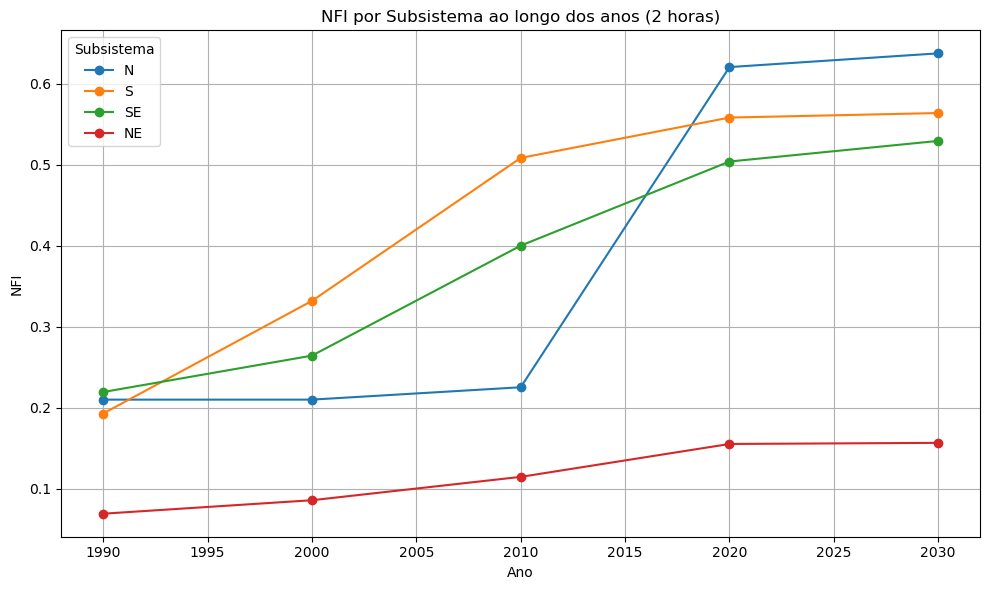

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for sistema in sistemas:
    dados = resultado[(resultado['sistema'] == sistema) & (resultado['horas'] == 2)]
    plt.plot(dados['ano'], dados['NFI'], marker='o', label=sistema)

plt.xlabel('Ano')
plt.ylabel('NFI')
plt.title('NFI por Subsistema ao longo dos anos (2 horas)')
plt.legend(title='Subsistema')
plt.grid(True)
plt.tight_layout()
plt.show()